Initial negative log marginal likelihood: 1026.6088024975056
Fitted sigma: 0.9426965967619905, Fitted eta: 1.0241553840892224


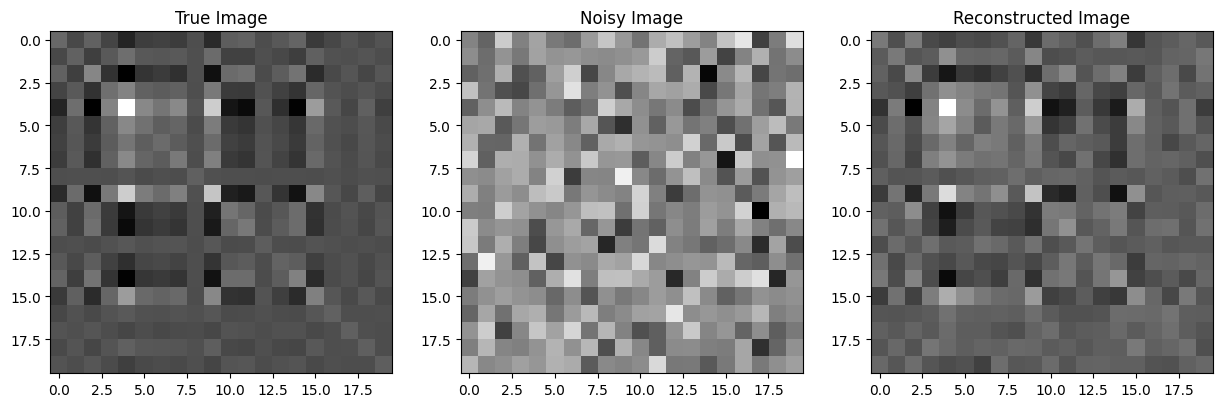

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from scipy.linalg import cholesky, inv, LinAlgError
from scipy.optimize import minimize
import scipy.stats as stats
from sklearn.datasets import make_spd_matrix
import itertools

class GaussianLinearModel:
    def __init__(self, A_theta, mu, Q_eta, Q_sigma_eta, sigma=1.0, eta=1.0):
        """
        Initialize the Gaussian Linear Model.

        Parameters:
        - A_theta: The design matrix that encodes the relationship between the true image and the noisy image.
        - mu: The mean of the true underlying image.
        - Q_eta: The precision matrix of the prior distribution for the true underlying image.
        - Q_sigma_eta: The precision matrix of the observation noise.
        - sigma: The parameter associated with observation noise.
        - eta: The parameter associated with the prior distribution and observation noise.
        """
        self.A_theta = A_theta
        self.mu = mu
        self.Q_eta = Q_eta
        self.Q_sigma_eta = Q_sigma_eta
        self.sigma = sigma
        self.eta = eta

    def log_det_cholesky(self, matrix):
        """
        Compute the log determinant of a matrix using Cholesky factorization.

        Parameters:
        - matrix: The input matrix.

        Returns:
        - The log determinant of the input matrix.
        """
        try:
            # Perform Cholesky decomposition
            L = cholesky(matrix, lower=True)
            # Compute the log determinant from the diagonal elements
            return 2 * np.sum(np.log(np.diag(L)))
        except LinAlgError:
            # Return negative infinity if the matrix is not positive definite
            return -np.inf

    def log_marginal_likelihood(self, params, y):
        """
        Compute the negative log marginal likelihood for the model parameters.

        Parameters:
        - params: Tuple (sigma, eta) to optimize.
        - y: Noisy observation data.

        Returns:
        - The negative log marginal likelihood.
        """
        sigma, eta = params
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = eta / sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the log determinants
        log_det_Q_eta = self.log_det_cholesky(self.Q_eta)
        log_det_Q_sigma_eta = self.log_det_cholesky(Q_sigma_eta)
        log_det_sum = self.log_det_cholesky(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the inverse of the sum of precision matrices
        Q_inv = np.linalg.inv(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the posterior mean given y
        mu_x_given_y = Q_inv @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        # Compute the first term
        term1 = float((mu_x_given_y - self.mu).T @ self.Q_eta @ (mu_x_given_y - self.mu))
        # Compute the second term
        term2 = float((y - self.A_theta @ mu_x_given_y).T @ Q_sigma_eta @ (y - self.A_theta @ mu_x_given_y))
        # Compute the likelihood
        likelihood = len(y) * np.log(2 * np.pi) + log_det_Q_eta + log_det_Q_sigma_eta - log_det_sum - term1 - term2
        return -0.5 * likelihood

    def fit(self, y):
        """
        Estimate the optimal parameters (sigma, eta) using maximum likelihood estimation.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - Tuple (sigma, eta) of optimized parameters.
        """
        # Minimize the negative log marginal likelihood
        result = minimize(self.log_marginal_likelihood, x0=[self.sigma, self.eta], args=(y,))
        # Update the sigma and eta parameters
        self.sigma, self.eta = result.x
        return self.sigma, self.eta

    def reconstruct(self, y):
        """
        Reconstruct the true image from the noisy observations.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - The reconstructed true image.
        """
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = self.eta / self.sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the inverse of the sum of precision matrices
        Q_inv = self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta
        mu_x_given_y = np.linalg.inv(Q_inv) @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        return mu_x_given_y


    def generate_data(self, X, sigma):
      """
      Generate noisy observations from a true image using instance-specific attributes.

      Parameters:
      - X: The true underlying image data.
      - sigma: The parameter associated with observation noise.

      Returns:
      - The noisy observations.
      """
      # Generate noise using the covariance matrix derived from the instance's precision matrix
      Sigma = inv(self.Q_sigma_eta)
      dim = self.Q_sigma_eta.shape[0]
      noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=Sigma)
      # Generate the noisy observations
      y = self.A_theta @ X + noise
      return y


def main():
    i = 20
    true_image = make_spd_matrix(i)
    true_image_vector = true_image.flatten()

    np.random.seed(42)
    A_theta = np.random.normal(size=(len(true_image_vector), len(true_image_vector)))
    mu = np.random.normal(size=(len(true_image_vector),))
    Q_eta = make_spd_matrix(len(true_image_vector))
    Q_sigma_eta = make_spd_matrix(len(true_image_vector))

    model = GaussianLinearModel(A_theta, mu, Q_eta, Q_sigma_eta)
    y = model.generate_data(true_image_vector, sigma=model.sigma)  # Corrected call
    noisy_image = y.reshape(true_image.shape)
    # Print negative log marginal likelihood for initial parameters
    initial_nll = model.log_marginal_likelihood((model.sigma, model.eta), y)
    print(f"Initial negative log marginal likelihood: {initial_nll}")

    # Fit model to data
    fitted_sigma, fitted_eta = model.fit(y)
    # Print the fitted values
    print(f"Fitted sigma: {fitted_sigma}, Fitted eta: {fitted_eta}")

    # Reconstruct true image
    reconstructed_image_vector = model.reconstruct(y)
    reconstructed_image = reconstructed_image_vector.reshape(true_image.shape)

    # Plot true, noisy, and reconstructed images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(true_image, cmap='gray')
    axes[0].set_title("True Image")
    axes[1].imshow(noisy_image, cmap='gray')
    axes[1].set_title("Noisy Image")
    axes[2].imshow(reconstructed_image, cmap='gray')
    axes[2].set_title("Reconstructed Image")
    plt.show()

# Execute the main function
main()



Initial negative log marginal likelihood: 5304.481437400119
Fitted sigma: 1.0796367776077747, Fitted eta: 1.0112848198586384


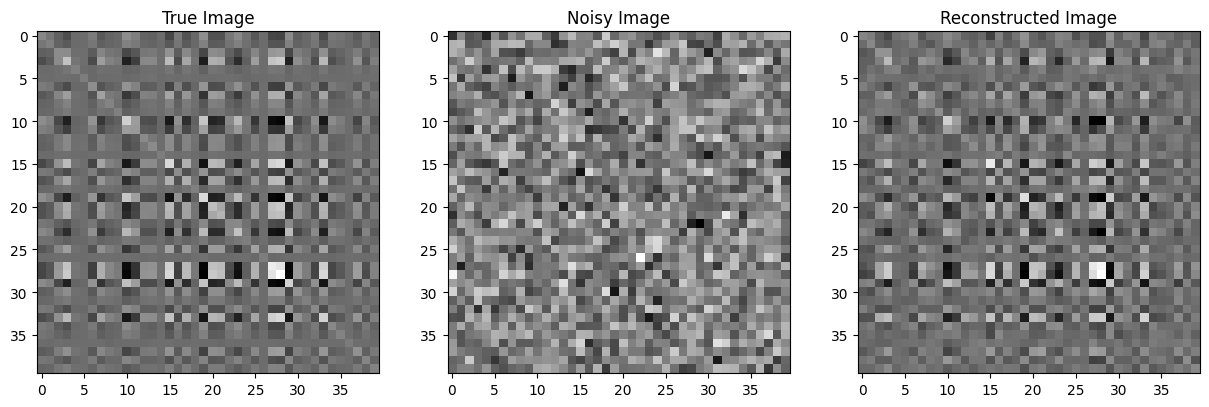

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from scipy.linalg import cholesky, inv, LinAlgError
from scipy.optimize import minimize
import scipy.stats as stats
from sklearn.datasets import make_spd_matrix
import itertools

class GaussianLinearModel:
    def __init__(self, A_theta, mu, Q_eta, Q_sigma_eta, sigma=1.0, eta=1.0):
        """
        Initialize the Gaussian Linear Model.

        Parameters:
        - A_theta: The design matrix that encodes the relationship between the true image and the noisy image.
        - mu: The mean of the true underlying image.
        - Q_eta: The precision matrix of the prior distribution for the true underlying image.
        - Q_sigma_eta: The precision matrix of the observation noise.
        - sigma: The parameter associated with observation noise.
        - eta: The parameter associated with the prior distribution and observation noise.
        """
        self.A_theta = A_theta
        self.mu = mu
        self.Q_eta = Q_eta
        self.Q_sigma_eta = Q_sigma_eta
        self.sigma = sigma
        self.eta = eta

    def log_det_cholesky(self, matrix):
        """
        Compute the log determinant of a matrix using Cholesky factorization.

        Parameters:
        - matrix: The input matrix.

        Returns:
        - The log determinant of the input matrix.
        """
        try:
            # Perform Cholesky decomposition
            L = cholesky(matrix, lower=True)
            # Compute the log determinant from the diagonal elements
            return 2 * np.sum(np.log(np.diag(L)))
        except LinAlgError:
            # Return negative infinity if the matrix is not positive definite
            return -np.inf

    def log_marginal_likelihood(self, params, y):
        """
        Compute the negative log marginal likelihood for the model parameters.

        Parameters:
        - params: Tuple (sigma, eta) to optimize.
        - y: Noisy observation data.

        Returns:
        - The negative log marginal likelihood.
        """
        sigma, eta = params
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = eta / sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the log determinants
        log_det_Q_eta = self.log_det_cholesky(self.Q_eta)
        log_det_Q_sigma_eta = self.log_det_cholesky(Q_sigma_eta)
        log_det_sum = self.log_det_cholesky(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the inverse of the sum of precision matrices
        Q_inv = np.linalg.inv(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the posterior mean given y
        mu_x_given_y = Q_inv @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        # Compute the first term
        term1 = float((mu_x_given_y - self.mu).T @ self.Q_eta @ (mu_x_given_y - self.mu))
        # Compute the second term
        term2 = float((y - self.A_theta @ mu_x_given_y).T @ Q_sigma_eta @ (y - self.A_theta @ mu_x_given_y))
        # Compute the likelihood
        likelihood = len(y) * np.log(2 * np.pi) + log_det_Q_eta + log_det_Q_sigma_eta - log_det_sum - term1 - term2
        return -0.5 * likelihood

    def fit(self, y):
        """
        Estimate the optimal parameters (sigma, eta) using maximum likelihood estimation.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - Tuple (sigma, eta) of optimized parameters.
        """
        # Minimize the negative log marginal likelihood
        result = minimize(self.log_marginal_likelihood, x0=[self.sigma, self.eta], args=(y,))
        # Update the sigma and eta parameters
        self.sigma, self.eta = result.x
        return self.sigma, self.eta

    def reconstruct(self, y):
        """
        Reconstruct the true image from the noisy observations.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - The reconstructed true image.
        """
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = self.eta / self.sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the inverse of the sum of precision matrices
        Q_inv = self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta
        mu_x_given_y = np.linalg.inv(Q_inv) @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        return mu_x_given_y


    def generate_data(self, X, sigma):
      """
      Generate noisy observations from a true image using instance-specific attributes.

      Parameters:
      - X: The true underlying image data.
      - sigma: The parameter associated with observation noise.

      Returns:
      - The noisy observations.
      """
      # Generate noise using the covariance matrix derived from the instance's precision matrix
      Sigma = inv(self.Q_sigma_eta)
      dim = self.Q_sigma_eta.shape[0]
      noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=Sigma)
      # Generate the noisy observations
      y = self.A_theta @ X + noise
      return y


def main():
    i = 40
    true_image = make_spd_matrix(i)
    true_image_vector = true_image.flatten()

    np.random.seed(42)
    A_theta = np.random.normal(size=(len(true_image_vector), len(true_image_vector)))
    mu = np.random.normal(size=(len(true_image_vector),))
    Q_eta = make_spd_matrix(len(true_image_vector))
    Q_sigma_eta = make_spd_matrix(len(true_image_vector))

    model = GaussianLinearModel(A_theta, mu, Q_eta, Q_sigma_eta)
    y = model.generate_data(true_image_vector, sigma=model.sigma)  # Corrected call
    noisy_image = y.reshape(true_image.shape)
    # Print negative log marginal likelihood for initial parameters
    initial_nll = model.log_marginal_likelihood((model.sigma, model.eta), y)
    print(f"Initial negative log marginal likelihood: {initial_nll}")

    # Fit model to data
    fitted_sigma, fitted_eta = model.fit(y)
    # Print the fitted values
    print(f"Fitted sigma: {fitted_sigma}, Fitted eta: {fitted_eta}")

    # Reconstruct true image
    reconstructed_image_vector = model.reconstruct(y)
    reconstructed_image = reconstructed_image_vector.reshape(true_image.shape)

    # Plot true, noisy, and reconstructed images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(true_image, cmap='gray')
    axes[0].set_title("True Image")
    axes[1].imshow(noisy_image, cmap='gray')
    axes[1].set_title("Noisy Image")
    axes[2].imshow(reconstructed_image, cmap='gray')
    axes[2].set_title("Reconstructed Image")
    plt.show()

# Execute the main function
main()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from scipy.linalg import cholesky, inv, LinAlgError
from scipy.optimize import minimize
import scipy.stats as stats
from sklearn.datasets import make_spd_matrix
import itertools

class GaussianLinearModel:
    def __init__(self, A_theta, mu, Q_eta, Q_sigma_eta, sigma=1.0, eta=1.0):
        """
        Initialize the Gaussian Linear Model.

        Parameters:
        - A_theta: The design matrix that encodes the relationship between the true image and the noisy image.
        - mu: The mean of the true underlying image.
        - Q_eta: The precision matrix of the prior distribution for the true underlying image.
        - Q_sigma_eta: The precision matrix of the observation noise.
        - sigma: The parameter associated with observation noise.
        - eta: The parameter associated with the prior distribution and observation noise.
        """
        self.A_theta = A_theta
        self.mu = mu
        self.Q_eta = Q_eta
        self.Q_sigma_eta = Q_sigma_eta
        self.sigma = sigma
        self.eta = eta

    def log_det_cholesky(self, matrix):
        """
        Compute the log determinant of a matrix using Cholesky factorization.

        Parameters:
        - matrix: The input matrix.

        Returns:
        - The log determinant of the input matrix.
        """
        try:
            # Perform Cholesky decomposition
            L = cholesky(matrix, lower=True)
            # Compute the log determinant from the diagonal elements
            return 2 * np.sum(np.log(np.diag(L)))
        except LinAlgError:
            # Return negative infinity if the matrix is not positive definite
            return -np.inf

    def log_marginal_likelihood(self, params, y):
        """
        Compute the negative log marginal likelihood for the model parameters.

        Parameters:
        - params: Tuple (sigma, eta) to optimize.
        - y: Noisy observation data.

        Returns:
        - The negative log marginal likelihood.
        """
        sigma, eta = params
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = eta / sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the log determinants
        log_det_Q_eta = self.log_det_cholesky(self.Q_eta)
        log_det_Q_sigma_eta = self.log_det_cholesky(Q_sigma_eta)
        log_det_sum = self.log_det_cholesky(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the inverse of the sum of precision matrices
        Q_inv = np.linalg.inv(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the posterior mean given y
        mu_x_given_y = Q_inv @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        # Compute the first term
        term1 = float((mu_x_given_y - self.mu).T @ self.Q_eta @ (mu_x_given_y - self.mu))
        # Compute the second term
        term2 = float((y - self.A_theta @ mu_x_given_y).T @ Q_sigma_eta @ (y - self.A_theta @ mu_x_given_y))
        # Compute the likelihood
        likelihood = len(y) * np.log(2 * np.pi) + log_det_Q_eta + log_det_Q_sigma_eta - log_det_sum - term1 - term2
        return -0.5 * likelihood

    def fit(self, y):
        """
        Estimate the optimal parameters (sigma, eta) using maximum likelihood estimation.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - Tuple (sigma, eta) of optimized parameters.
        """
        # Minimize the negative log marginal likelihood
        result = minimize(self.log_marginal_likelihood, x0=[self.sigma, self.eta], args=(y,))
        # Update the sigma and eta parameters
        self.sigma, self.eta = result.x
        return self.sigma, self.eta

    def reconstruct(self, y):
        """
        Reconstruct the true image from the noisy observations.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - The reconstructed true image.
        """
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = self.eta / self.sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the inverse of the sum of precision matrices
        Q_inv = self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta
        mu_x_given_y = np.linalg.inv(Q_inv) @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        return mu_x_given_y


    def generate_data(self, X, sigma):
      """
      Generate noisy observations from a true image using instance-specific attributes.

      Parameters:
      - X: The true underlying image data.
      - sigma: The parameter associated with observation noise.

      Returns:
      - The noisy observations.
      """
      # Generate noise using the covariance matrix derived from the instance's precision matrix
      Sigma = inv(self.Q_sigma_eta)
      dim = self.Q_sigma_eta.shape[0]
      noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=Sigma)
      # Generate the noisy observations
      y = self.A_theta @ X + noise
      return y


def main():
    i = 100
    true_image = make_spd_matrix(i)
    true_image_vector = true_image.flatten()

    np.random.seed(42)
    A_theta = np.random.normal(size=(len(true_image_vector), len(true_image_vector)))
    mu = np.random.normal(size=(len(true_image_vector),))
    Q_eta = make_spd_matrix(len(true_image_vector))
    Q_sigma_eta = make_spd_matrix(len(true_image_vector))

    model = GaussianLinearModel(A_theta, mu, Q_eta, Q_sigma_eta)
    y = model.generate_data(true_image_vector, sigma=model.sigma)  # Corrected call
    noisy_image = y.reshape(true_image.shape)
    # Print negative log marginal likelihood for initial parameters
    initial_nll = model.log_marginal_likelihood((model.sigma, model.eta), y)
    print(f"Initial negative log marginal likelihood: {initial_nll}")

    # Fit model to data
    fitted_sigma, fitted_eta = model.fit(y)
    # Print the fitted values
    print(f"Fitted sigma: {fitted_sigma}, Fitted eta: {fitted_eta}")

    # Reconstruct true image
    reconstructed_image_vector = model.reconstruct(y)
    reconstructed_image = reconstructed_image_vector.reshape(true_image.shape)

    # Plot true, noisy, and reconstructed images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(true_image, cmap='gray')
    axes[0].set_title("True Image")
    axes[1].imshow(noisy_image, cmap='gray')
    axes[1].set_title("Noisy Image")
    axes[2].imshow(reconstructed_image, cmap='gray')
    axes[2].set_title("Reconstructed Image")
    plt.show()

# Execute the main function
main()



Initial negative log marginal likelihood: 42018.34844378601


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from scipy.linalg import cholesky, inv, LinAlgError
from scipy.optimize import minimize
import scipy.stats as stats
from sklearn.datasets import make_spd_matrix
import itertools
from scipy.sparse import diags
from scipy.sparse.linalg import inv
from scipy.linalg import eigh

class GaussianLinearModel:
    def __init__(self, A_theta, mu, Q_eta, Q_sigma_eta, sigma=1.0, eta=1.0):
        """
        Initialize the Gaussian Linear Model.

        Parameters:
        - A_theta: The design matrix that encodes the relationship between the true image and the noisy image.
        - mu: The mean of the true underlying image.
        - Q_eta: The precision matrix of the prior distribution for the true underlying image.
        - Q_sigma_eta: The precision matrix of the observation noise.
        - sigma: The parameter associated with observation noise.
        - eta: The parameter associated with the prior distribution and observation noise.
        """
        self.A_theta = A_theta
        self.mu = mu
        self.Q_eta = Q_eta
        self.Q_sigma_eta = Q_sigma_eta
        self.sigma = sigma
        self.eta = eta

    def log_det_cholesky(self, matrix):
        """
        Compute the log determinant of a matrix using Cholesky factorization.

        Parameters:
        - matrix: The input matrix.

        Returns:
        - The log determinant of the input matrix.
        """
        try:
            # Perform Cholesky decomposition
            L = cholesky(matrix, lower=True)
            # Compute the log determinant from the diagonal elements
            return 2 * np.sum(np.log(np.diag(L)))
        except LinAlgError:
            # Return negative infinity if the matrix is not positive definite
            return -np.inf

    def log_marginal_likelihood(self, params, y):
        """
        Compute the negative log marginal likelihood for the model parameters.

        Parameters:
        - params: Tuple (sigma, eta) to optimize.
        - y: Noisy observation data.

        Returns:
        - The negative log marginal likelihood.
        """
        sigma, eta = params
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = eta / sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the log determinants
        log_det_Q_eta = self.log_det_cholesky(self.Q_eta)
        log_det_Q_sigma_eta = self.log_det_cholesky(Q_sigma_eta)
        log_det_sum = self.log_det_cholesky(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the inverse of the sum of precision matrices
        Q_inv = np.linalg.inv(self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta)
        # Compute the posterior mean given y
        mu_x_given_y = Q_inv @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        # Compute the first term
        term1 = float((mu_x_given_y - self.mu).T @ self.Q_eta @ (mu_x_given_y - self.mu))
        # Compute the second term
        term2 = float((y - self.A_theta @ mu_x_given_y).T @ Q_sigma_eta @ (y - self.A_theta @ mu_x_given_y))
        # Compute the likelihood
        likelihood = len(y) * np.log(2 * np.pi) + log_det_Q_eta + log_det_Q_sigma_eta - log_det_sum - term1 - term2
        return -0.5 * likelihood

    def fit(self, y):
        """
        Estimate the optimal parameters (sigma, eta) using maximum likelihood estimation.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - Tuple (sigma, eta) of optimized parameters.
        """
        # Minimize the negative log marginal likelihood
        result = minimize(self.log_marginal_likelihood, x0=[self.sigma, self.eta], args=(y,))
        # Update the sigma and eta parameters
        self.sigma, self.eta = result.x
        return self.sigma, self.eta

    def reconstruct(self, y):
        """
        Reconstruct the true image from the noisy observations.

        Parameters:
        - y: Noisy observation data.

        Returns:
        - The reconstructed true image.
        """
        # Compute the precision matrix for the observation noise
        Q_sigma_eta = self.eta / self.sigma**2 * self.Q_sigma_eta
        # Transpose of A_theta
        A_theta_transpose = self.A_theta.T
        # Compute the inverse of the sum of precision matrices
        Q_inv = self.Q_eta + A_theta_transpose @ Q_sigma_eta @ self.A_theta
        mu_x_given_y = np.linalg.inv(Q_inv) @ (
            self.Q_eta @ self.mu + A_theta_transpose @ Q_sigma_eta @ y)
        return mu_x_given_y


    def generate_data(self, X, sigma):
      """
      Generate noisy observations from a true image using instance-specific attributes.

      Parameters:
      - X: The true underlying image data.
      - sigma: The parameter associated with observation noise.

      Returns:
      - The noisy observations.
      """
      # Generate noise using the covariance matrix derived from the instance's precision matrix
      Sigma = inv(self.Q_sigma_eta)
      dim = self.Q_sigma_eta.shape[0]
      noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=Sigma)
      # Generate the noisy observations
      y = self.A_theta @ X + noise
      return y
def make_pentadiagonal_spd_matrix(size):
    # Generate random diagonals while ensuring the matrix is symmetric and positive definite
    k1 = np.random.uniform(1, 2, size)  # Main diagonal
    k2 = np.random.uniform(0.1, 1, size - 1)  # First off-diagonals
    k3 = np.random.uniform(0.1, 0.5, size - 2)  # Second off-diagonals
    diagonals = [k3, k2, k1, k2, k3]
    offsets = [-2, -1, 0, 1, 2]
    A = diags(diagonals, offsets, shape=(size, size), format='csc')
    A = A @ A.T  # Ensure positive definiteness
    return A

def main():
    i = 20
    true_image = make_spd_matrix(i)
    true_image_vector = true_image.flatten()

    np.random.seed(42)
    A_theta = np.random.normal(size=(len(true_image_vector), len(true_image_vector)))
    mu = np.random.normal(size=(len(true_image_vector),))
    # Creating pentadiagonal SPD matrices and converting them to dense format
    Q_eta = make_pentadiagonal_spd_matrix(len(true_image_vector))
    Q_sigma_eta = make_pentadiagonal_spd_matrix(len(true_image_vector))

    model = GaussianLinearModel(A_theta, mu, Q_eta, Q_sigma_eta)
    y = model.generate_data(true_image_vector, sigma=model.sigma)  # Corrected call
    noisy_image = y.reshape(true_image.shape)
    # Print negative log marginal likelihood for initial parameters
    initial_nll = model.log_marginal_likelihood((model.sigma, model.eta), y)
    print(f"Initial negative log marginal likelihood: {initial_nll}")

    # Fit model to data
    fitted_sigma, fitted_eta = model.fit(y)
    # Print the fitted values
    print(f"Fitted sigma: {fitted_sigma}, Fitted eta: {fitted_eta}")

    # Reconstruct true image
    reconstructed_image_vector = model.reconstruct(y)
    reconstructed_image = reconstructed_image_vector.reshape(true_image.shape)

    # Plot true, noisy, and reconstructed images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(true_image, cmap='gray')
    axes[0].set_title("True Image")
    axes[1].imshow(noisy_image, cmap='gray')
    axes[1].set_title("Noisy Image")
    axes[2].imshow(reconstructed_image, cmap='gray')
    axes[2].set_title("Reconstructed Image")
    plt.show()

# Execute the main function
main()

